In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
import yaml
from tqdm import tqdm
import torchvision.transforms.v2 as v2
from copy import deepcopy
import sys
sys.path.append("/n/home11/sambt/phlab-neurips25")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

from models.litmodels import SimCLRModel
from models.networks import CustomResNet, MLP
from models.losses import MMDLoss, RBF
from data.datasets import CIFAR10Dataset
from data.cifar import CIFAR5MDataset
import data.data_utils as dutils

from sklearn.metrics import roc_auc_score, top_k_accuracy_score
from utils.plotting import make_corner, make_corner2

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# evaluate

In [2]:
from data.datasets import JetClassDataset
dset = JetClassDataset(["qcd","ttbar","wqq","zqq","hbb"],
                       "/n/home11/sambt/phlab-neurips25/configs/jetclass_data_configs/JetClass_full.yaml",
                       limit_test_files=1,
                       batch_size=512,
                       num_workers=1)

In [3]:
# T = 0.1
checkpoint = "/n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_withClassifier_labNoise0.1/lightning_logs/83htf511/checkpoints/epoch=49-step=5000.ckpt"
model = SimCLRModel.load_from_checkpoint(checkpoint)
model = model.eval()
model = model.to(device)

test_loader = dset.test_dataloader()

cfg_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0.1, 'attn_dropout': 0.1, 'activation_dropout': 0.1, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
cfg_cls_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
Label noise enabled with set: [0, 1, 2, 3]


/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['encoder'])`.
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'projector' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['projector'])`.


In [4]:
n_processed = 0
n_per_class = {}
all_embeddings = []
all_labels = []
for batch in tqdm(test_loader):
    x, labels, observers = batch
    labels = labels['_label_'].numpy()
    for k in x.keys():
        x[k]=x[k].to(device)
    with torch.no_grad():
        embeds = model.encoder(x).cpu().numpy()
    del x
    torch.cuda.empty_cache()
    all_embeddings.append(embeds)
    all_labels.append(labels)

0it [00:00, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/torch/nn/functional.py:5193: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
977it [05:21,  3.04it/s]


In [5]:
all_embeddings = np.concatenate(all_embeddings)
all_labels = np.concatenate(all_labels)
np.savez("jetClass_embeddings_T0.1_noise0.1.npz",data=all_embeddings,labels=all_labels)

In [6]:
# T = 0.1 full space trained with Hbb
checkpoint = "/n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_withClassifier_withHbb_labNoise0.1/lightning_logs/1wsnb9xo/checkpoints/epoch=8-step=900.ckpt"
model = SimCLRModel.load_from_checkpoint(checkpoint)
model = model.eval()
model = model.to(device)

test_loader = dset.test_dataloader()

cfg_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0.1, 'attn_dropout': 0.1, 'activation_dropout': 0.1, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
cfg_cls_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
Label noise enabled with set: [0, 1, 2, 3, 4]


In [7]:
n_processed = 0
n_per_class = {}
all_embeddings = []
all_labels = []
for batch in tqdm(test_loader):
    x, labels, observers = batch
    labels = labels['_label_'].numpy()
    for k in x.keys():
        x[k]=x[k].to(device)
    with torch.no_grad():
        embeds = model.encoder(x).cpu().numpy()
    del x
    torch.cuda.empty_cache()
    all_embeddings.append(embeds)
    all_labels.append(labels)

977it [05:06,  3.19it/s]


In [8]:
all_embeddings = np.concatenate(all_embeddings)
all_labels = np.concatenate(all_labels)
np.savez("jetClassWithHbb_embeddings_T0.1_noise0.1.npz",data=all_embeddings,labels=all_labels)

# train supervised classifier T = 0.1

In [9]:
from sklearn.model_selection import train_test_split
data = np.load("jetClass_embeddings_T0.1_noise0.1.npz")
bkg = data['data'][data['labels'] != 4]
bkg_trueLabels = data['labels'][data['labels'] != 4]
sig = data['data'][data['labels'] == 4]
sig_trueLabels = data['labels'][data['labels'] == 4]
np.random.shuffle(bkg)
np.random.shuffle(sig)

bkg_train, bkg_test, bkg_trueLabels_train, bkg_trueLabels_test = train_test_split(bkg,bkg_trueLabels,test_size=0.5,random_state=84901)
sig_train, sig_test, sig_trueLabels_train, sig_trueLabels_test, = train_test_split(sig,sig_trueLabels,test_size=0.5,random_state=56813)

train_data = np.concatenate([bkg_train[:len(sig_train)],sig_train],axis=0)
train_labels = np.concatenate([np.zeros(len(bkg_train[:len(sig_train)])),np.ones(len(sig_train))]).reshape(-1,1)
perm = np.random.permutation(len(train_data))
train_data = train_data[perm]
train_labels = train_labels[perm]

train_data, val_data, train_labels, val_labels = train_test_split(train_data,train_labels,test_size=0.1)

train_dset = TensorDataset(torch.tensor(train_data),torch.tensor(train_labels))
val_dset = TensorDataset(torch.tensor(val_data),torch.tensor(val_labels))
train_loader = DataLoader(train_dset,batch_size=512,shuffle=True)
val_loader = DataLoader(val_dset,batch_size=512,shuffle=True)

100%|██████████| 100/100 [02:06<00:00,  1.26s/it]


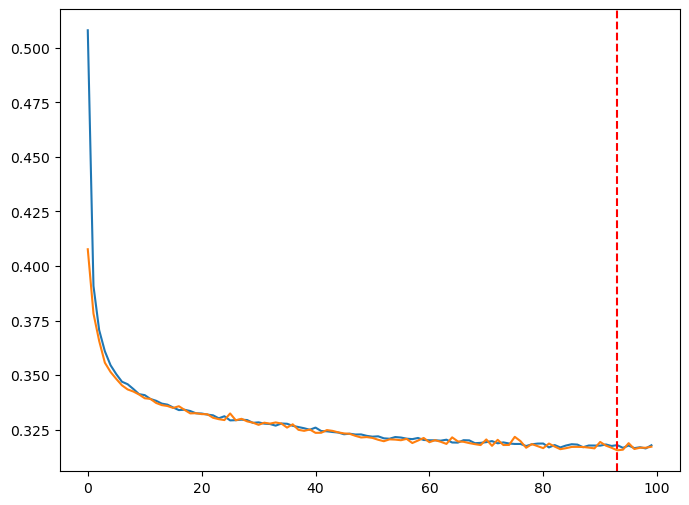

In [10]:
model = MLP(train_data.shape[1],[32,32],1,dropout=0.1).to(device)
num_epochs = 100
lr = 1e-3
optimizer = torch.optim.AdamW(model.parameters(),lr=lr)

train_loss = []
val_loss = []
best_loss = 1e6
best_state = None
best_ep = None
patience = 0
patience_lim = 10
for i in tqdm(range(num_epochs)):
    tlosses = []
    if patience == patience_lim:
        print('stopped improving')
        break
    for batch in train_loader:
        x,lab = batch
        preds = model(x.to(device))
        loss = F.binary_cross_entropy_with_logits(preds,lab.to(device))
        tlosses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss.append(np.mean(tlosses))
    
    vlosses = []
    for batch in train_loader:
        x,lab = batch
        with torch.no_grad():
            preds = model(x.to(device))
        loss = F.binary_cross_entropy_with_logits(preds,lab.to(device))
        vlosses.append(loss.item())
    val_loss.append(np.mean(vlosses))
    if val_loss[-1] < best_loss:
        best_loss = val_loss[-1]
        best_state = model.state_dict()
        best_ep = i
        patience = 0
    else:
        patience += 1

plt.figure(figsize=(8,6))
x = np.arange(len(train_loss))
plt.plot(x,train_loss,label='train')
plt.plot(x,val_loss,label='val')
plt.axvline(best_ep,linestyle='--',color='red')

In [11]:
model.load_state_dict(best_state)
model = model.eval()
torch.save(model,"jetClass_supClassifier_T0.1_noise0.1.pt")

In [12]:
model = torch.load("jetClass_supClassifier_T0.1_noise0.1.pt").to(device)

/tmp/ipykernel_2330820/790806478.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("jetClass_supClassifier_T0.1_noise0.1.pt").to(device)


In [13]:
act = nn.Sigmoid()
#act = nn.Identity()
bkg_test_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(bkg_test)),batch_size=512,shuffle=False):
    with torch.no_grad():
        bkg_test_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
bkg_test_preds = np.concatenate(bkg_test_preds)

sig_test_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(sig_test)),batch_size=512,shuffle=False):
    with torch.no_grad():
        sig_test_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
sig_test_preds = np.concatenate(sig_test_preds)

In [14]:
all_preds = np.concatenate([bkg_test_preds,sig_test_preds])
all_labels = np.concatenate([bkg_trueLabels_test,sig_trueLabels_test])
shuf = np.random.permutation(len(all_preds))
all_preds = all_preds[shuf]
all_labels = all_labels[shuf]

np.savez("jetClass_classPreds_T0.1_noise0.1.npz",data=all_preds,labels=all_labels)

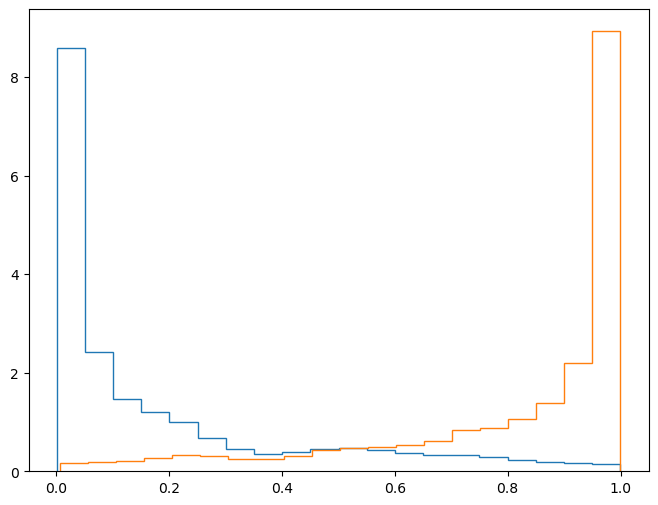

In [15]:
plt.figure(figsize=(8,6))
bins = 20
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

In [16]:
from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.01,0.02,0.05,0.1]
iNBkg = 10_000
Ntoys = 1000
iNBins = 100

pvalues = []
psigmas = []
zscores = []
zsigmas = []
for sf in tqdm(sig_fracs):
    ps = []
    zs = []
    for i in range(Ntoys):
        iNSig = int(sf*iNBkg)
        perm = np.random.permutation(len(bkg_test_preds))
        iBkg = bkg_test_preds[perm][:iNBkg]
        iRef = bkg_test_preds[perm][iNBkg:]
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=False)
        iData = np.concatenate([iBkg,iSig])
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=50)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

 85%|████████▍ | 11/13 [01:58<00:21, 10.81s/it]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/py

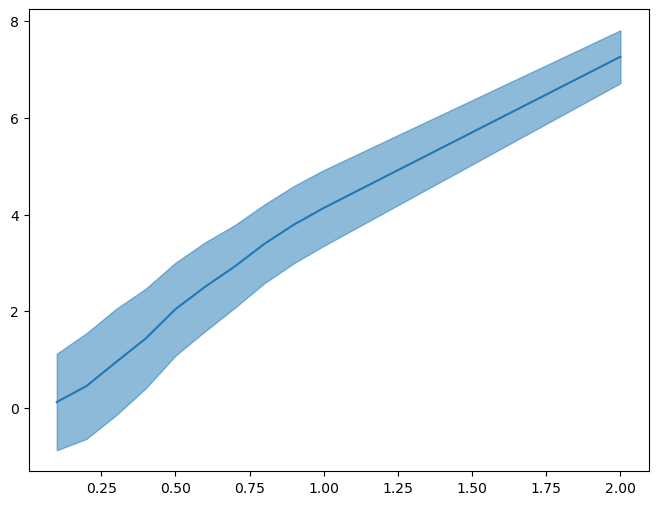

In [17]:
plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

In [18]:
np.savez("jetClass_T0.1_idealZscores_LRtestWithFit_nbkg10k_noise0.1.npz",zscores=np.array(zscores),fracs=np.array(sig_fracs))

# train supervised classifier T = 0.1 w/ full space including hbb

In [19]:
from sklearn.model_selection import train_test_split
data = np.load("jetClassWithHbb_embeddings_T0.1_noise0.1.npz")
bkg = data['data'][data['labels'] != 4]
bkg_trueLabels = data['labels'][data['labels'] != 4]
sig = data['data'][data['labels'] == 4]
sig_trueLabels = data['labels'][data['labels'] == 4]
np.random.shuffle(bkg)
np.random.shuffle(sig)

bkg_train, bkg_test, bkg_trueLabels_train, bkg_trueLabels_test = train_test_split(bkg,bkg_trueLabels,test_size=0.5, random_state=12413)
sig_train, sig_test, sig_trueLabels_train, sig_trueLabels_test, = train_test_split(sig,sig_trueLabels,test_size=0.5, random_state=15789)

train_data = np.concatenate([bkg_train[:len(sig_train)],sig_train],axis=0)
train_labels = np.concatenate([np.zeros(len(bkg_train[:len(sig_train)])),np.ones(len(sig_train))]).reshape(-1,1)
perm = np.random.permutation(len(train_data))
train_data = train_data[perm]
train_labels = train_labels[perm]

train_data, val_data, train_labels, val_labels = train_test_split(train_data,train_labels,test_size=0.1)

train_dset = TensorDataset(torch.tensor(train_data),torch.tensor(train_labels))
val_dset = TensorDataset(torch.tensor(val_data),torch.tensor(val_labels))
train_loader = DataLoader(train_dset,batch_size=512,shuffle=True)
val_loader = DataLoader(val_dset,batch_size=512,shuffle=True)

 89%|████████▉ | 89/100 [01:52<00:13,  1.27s/it]

stopped improving


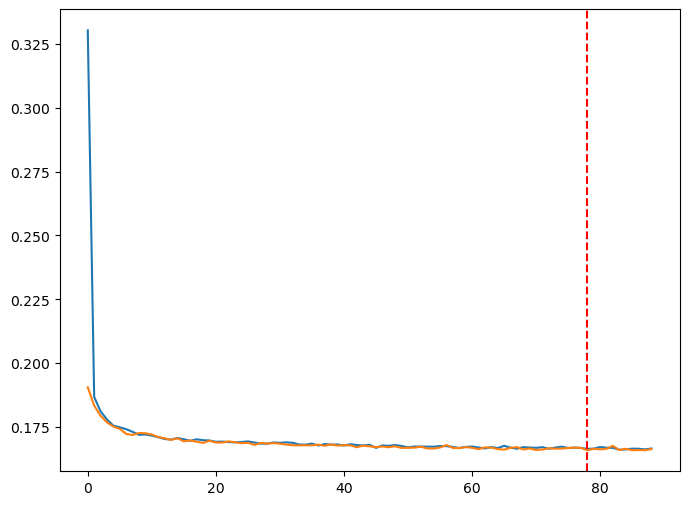

In [20]:
model = MLP(train_data.shape[1],[32,32,32],1,dropout=0.1).to(device)
num_epochs = 100
lr = 1e-3
optimizer = torch.optim.AdamW(model.parameters(),lr=lr)

train_loss = []
val_loss = []
best_loss = 1e6
best_state = None
best_ep = None
patience = 0
patience_lim = 10
for i in tqdm(range(num_epochs)):
    tlosses = []
    if patience == patience_lim:
        print('stopped improving')
        break
    for batch in train_loader:
        x,lab = batch
        preds = model(x.to(device))
        loss = F.binary_cross_entropy_with_logits(preds,lab.to(device))
        tlosses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss.append(np.mean(tlosses))
    
    vlosses = []
    for batch in train_loader:
        x,lab = batch
        with torch.no_grad():
            preds = model(x.to(device))
        loss = F.binary_cross_entropy_with_logits(preds,lab.to(device))
        vlosses.append(loss.item())
    val_loss.append(np.mean(vlosses))
    if val_loss[-1] < best_loss:
        best_loss = val_loss[-1]
        best_state = model.state_dict()
        best_ep = i
        patience = 0
    else:
        patience += 1

plt.figure(figsize=(8,6))
x = np.arange(len(train_loss))
plt.plot(x,train_loss,label='train')
plt.plot(x,val_loss,label='val')
plt.axvline(best_ep,linestyle='--',color='red')

In [21]:
model.load_state_dict(best_state)
model = model.eval()
torch.save(model,"jetClassWithHbb_supClassifier_T0.1_noise0.1.pt")

In [22]:
model = torch.load("jetClassWithHbb_supClassifier_T0.1_noise0.1.pt").to(device)

/tmp/ipykernel_2330820/307138837.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("jetClassWithHbb_supClassifier_T0.1_noise0.1.pt").to(device)


In [23]:
act = nn.Sigmoid()
#act = nn.Identity()
bkg_test_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(bkg_test)),batch_size=512,shuffle=False):
    with torch.no_grad():
        bkg_test_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
bkg_test_preds = np.concatenate(bkg_test_preds)

sig_test_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(sig_test)),batch_size=512,shuffle=False):
    with torch.no_grad():
        sig_test_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
sig_test_preds = np.concatenate(sig_test_preds)

In [24]:
all_preds = np.concatenate([bkg_test_preds,sig_test_preds])
all_labels = np.concatenate([bkg_trueLabels_test,sig_trueLabels_test])
shuf = np.random.permutation(len(all_preds))
all_preds = all_preds[shuf]
all_labels = all_labels[shuf]

np.savez("jetClassWithHbb_classPreds_T0.1_noise0.1.npz",data=all_preds,labels=all_labels)

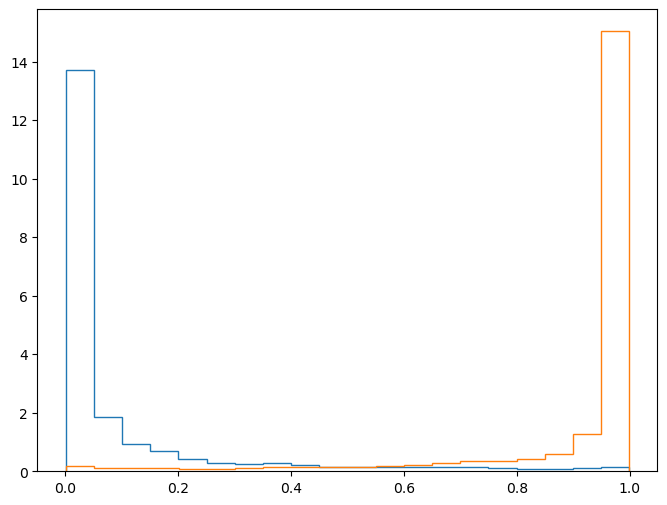

In [25]:
plt.figure(figsize=(8,6))
bins=20
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

In [26]:
from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.01,0.02,0.05,0.1]
iNBkg = 10_000
Ntoys = 1000
iNBins = 100

pvalues = []
psigmas = []
zscores = []
zsigmas = []
for sf in tqdm(sig_fracs):
    ps = []
    zs = []
    for i in range(Ntoys):
        iNSig = int(sf*iNBkg)
        perm = np.random.permutation(len(bkg_test_preds))
        iBkg = bkg_test_preds[perm][:iNBkg]
        iRef = bkg_test_preds[perm][iNBkg:]
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=False)
        iData = np.concatenate([iBkg,iSig])
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=50)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

100%|██████████| 13/13 [02:19<00:00, 10.73s/it]


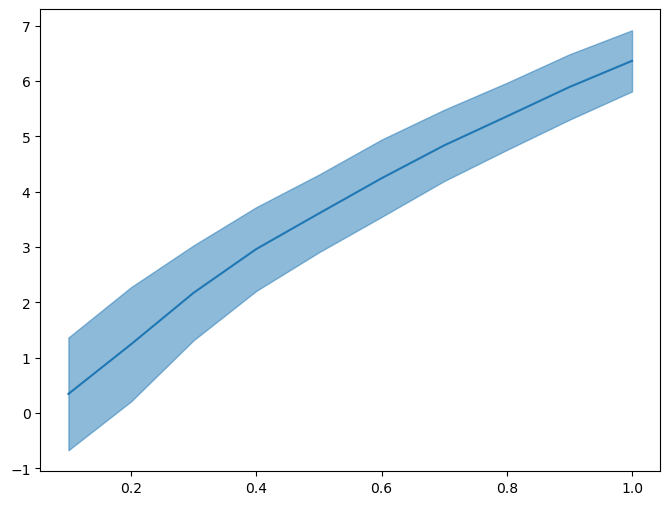

In [27]:
plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

In [28]:
np.savez("jetClassWithHbb_T0.1_idealZscores_LRtestWithFit_nbkg10k_noise0.1.npz",zscores=np.array(zscores),fracs=np.array(sig_fracs))